---
title: "Forward vs. inverse parameterisation"
short_title: "02 · Forward vs. inverse"
subtitle: "One bijection, two directions — and how to differentiate through the iterative one"
description: >
  A flow is a bijection, so it runs both ways: forward (data -> latent) for
  density evaluation, inverse (latent -> data) for sampling. Usually one
  direction is closed-form and the other is a root-find. We invert a
  mixture-CDF with optimistix, then differentiate through that fixed point the
  right way — by the implicit-function theorem / adjoint, not by unrolling the
  solver — and finish on the density-estimation vs. generation trade-off that
  splits MAF from IAF.
---

(sec-nb-02)=
# 02 — Forward vs. inverse parameterisation

A normalizing flow is a *bijection* $T$, so it can be run in either direction.
That sounds symmetric, but it almost never is: one direction is a closed-form
expression and the other needs an iterative solve. Which direction you make
cheap decides whether your flow is good at *density estimation* or at
*sampling* — and the iterative direction raises a subtle question: **how do you
take gradients through a root-finder?** This notebook answers both.

**What you will see**

- The two operations a flow supports — `log_prob` (forward) and `sample`
  (inverse) — and which direction each needs.
- A mixture-CDF whose **forward** $F(x)$ is one closed-form line but whose
  **inverse** $F^{-1}(u)$ we solve with `optimistix.root_find` (bisection).
- **Gradients both ways**: the forward gradient is plain autodiff; the inverse
  gradient must come from the **implicit-function theorem / adjoint** — naively
  unrolling the solver gives a *wrong (zero!)* gradient.
- A real `gauss_flows` flow where `log_prob` is **~39×** faster than `sample`,
  and the `flowjax.Invert` parameterisation choice (the MAF ↔ IAF duality).

In [1]:
import warnings

warnings.filterwarnings("ignore")

import time

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.stats as jstats
import matplotlib.pyplot as plt
import numpy as np
import optimistix as optx

from _style import style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(2)

## 1. A flow runs both ways

Let $z = T(x)$ map data to a standard-Gaussian latent. The two things we ever
ask of a flow use *opposite* directions:

| operation | direction | needs | used for |
|---|---|---|---|
| `log_prob(x)` | **forward** $x \to z$ | $T(x)$ and $\log\lvert\det J_T(x)\rvert$ | density estimation, MLE training |
| `sample()` | **inverse** $z \to x$ | $T^{-1}(z)$, $z\sim\mathcal{N}(0,I)$ | generation, simulation |

Both are always *possible* (that's what "bijection" means), but their *cost*
and their *differentiability* can differ sharply. The culprit is the marginal
transform.

## 2. Analytic forward, iterative inverse — with `optimistix`

The atom of Gaussianization is the per-coordinate map $z = \Phi^{-1}(F(x))$,
where $F$ is a **mixture-of-Gaussians CDF**,

$$
F(x) = \sum_{k} w_k\,\Phi\!\Big(\frac{x-\mu_k}{\sigma_k}\Big),
\qquad
F'(x) = \sum_k w_k\,\phi\!\Big(\frac{x-\mu_k}{\sigma_k}\Big)\frac1{\sigma_k}.
$$

Forward ($x \to u = F(x)$) is one closed-form sum. Inverse ($u \to x =
F^{-1}(u)$) has *no* closed form, so we frame it as a **root-find**: solve
$g(x) = F(x) - u = 0$. We hand that to
[`optimistix`](https://github.com/patrick-kidger/optimistix)
{cite}`kidger2021ndes` — the same solver library `gauss_flows` depends on —
using its bracketing `Bisection` solver, which is bullet-proof because $F$ is
monotone.

In [2]:
w = jnp.array([0.4, 0.35, 0.25])
mu = jnp.array([-1.5, 0.3, 2.0])
sd = jnp.array([0.4, 0.6, 0.5])


def F(x):  # mixture-of-Gaussians CDF (forward), closed form
    return jnp.sum(w * jstats.norm.cdf(x, mu, sd))


def Fprime(x):  # F'(x) = mixture density; needed for the inverse gradient
    return jnp.sum(w * jstats.norm.pdf(x, mu, sd))


F_v = jax.vmap(F)

_solver = optx.Bisection(rtol=1e-10, atol=1e-12)


def invF(u, max_steps=200):
    """x = F^{-1}(u) via optimistix bisection on g(x) = F(x) - u."""
    sol = optx.root_find(
        lambda x, args: F(x) - args, _solver, 0.0, args=u,
        options=dict(lower=-12.0, upper=12.0), max_steps=max_steps, throw=False,
    )
    return sol.value


# Round-trip: push real samples forward, then recover them with the solver.
x_true = jnp.asarray(rng.normal(0.3, 1.2, size=400))
u_targets = F_v(x_true)
x_rec = jax.vmap(invF)(u_targets)
print("forward F(x): closed form, one evaluation")
print(f"inverse F^-1(u) via optimistix: max|x - x_rec| = "
      f"{float(jnp.max(jnp.abs(x_true - x_rec))):.2e}")

# Accuracy vs. solver budget: bisection error falls geometrically (~2^-n).
steps = np.arange(1, 46)
u0 = 0.7
err_vs_steps = np.array(
    [abs(float(F(invF(u0, max_steps=int(k))) - u0)) for k in steps]
)

forward F(x): closed form, one evaluation
inverse F^-1(u) via optimistix: max|x - x_rec| = 1.63e-10


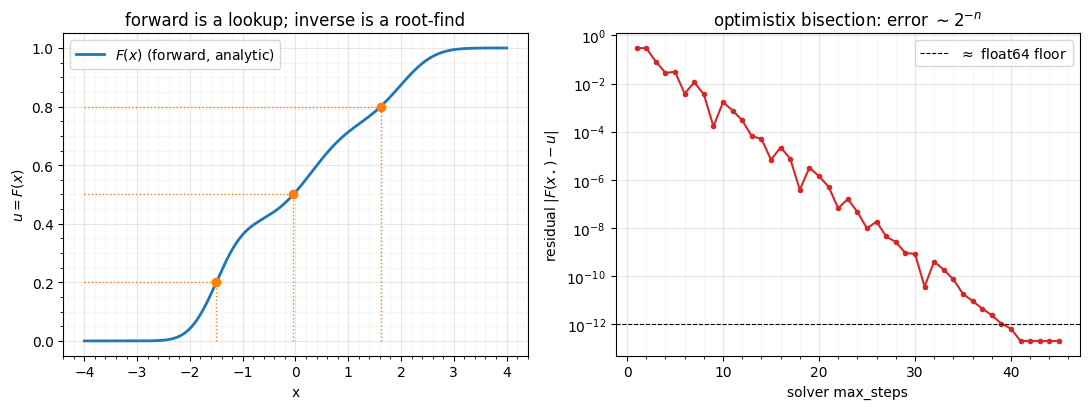

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

xg = jnp.linspace(-4, 4, 500)
axes[0].plot(xg, F_v(xg), color="tab:blue", lw=2, label="$F(x)$ (forward, analytic)")
for u in [0.2, 0.5, 0.8]:
    xr = float(invF(jnp.asarray(u)))
    axes[0].hlines(u, -4, xr, color="tab:orange", lw=1, ls=":")
    axes[0].vlines(xr, 0, u, color="tab:orange", lw=1, ls=":")
    axes[0].plot(xr, u, "o", color="tab:orange", ms=6)
axes[0].set(title="forward is a lookup; inverse is a root-find",
            xlabel="x", ylabel="$u = F(x)$")
axes[0].legend(loc="upper left")
style_ax(axes[0])

axes[1].semilogy(steps, err_vs_steps, "-o", color="tab:red", ms=3)
axes[1].axhline(1e-12, color="k", lw=0.8, ls="--", label=r"$\approx$ float64 floor")
axes[1].set(title=r"optimistix bisection: error $\sim 2^{-n}$",
            xlabel="solver max_steps", ylabel=r"residual $|F(x_\star) - u|$")
axes[1].legend()
style_ax(axes[1])
fig.tight_layout()

Left: inverting $F$ means reading the curve right-to-left — there is no formula,
so `optimistix` hunts for the $x$ that lands on each target $u$. Right: the
residual falls geometrically with the solver budget, hitting the float64 floor
in ~40 steps. Accurate and robust — but it is a *loop*, which raises the real
question for training a flow: **what is the gradient of that loop?**

## 3. Gradients: forward, inverse, and the fixed-point adjoint

To train a flow by gradient descent we differentiate both directions. One is
trivial; the other is a classic trap.

**Forward — just autodiff.** $u = F(x)$ is an explicit closed-form expression,
so `jax.grad` differentiates it directly. Note the forward derivative *is* the
mixture density, $F'(x)$ — the very quantity that enters the log-det.

**Inverse — do *not* differentiate the solver.** The inverse $x_\star =
F^{-1}(u)$ is not an expression; it is defined *implicitly* as the solution of
$F(x_\star) - u = 0$. The naive idea — unroll the bisection loop and
backprop through every iteration — fails for two reasons: it costs memory
proportional to the iteration count, and bisection's bracket updates are
`where(F(mid) < u, …)` comparisons, which are **piecewise constant**. Their
derivative is zero, so autodiff through the unrolled loop returns a gradient of
**exactly 0** even though the root it found is perfect.

In [4]:
def invF_unrolled(u, n=50):
    """Inverse by an unrolled bisection loop — correct value, BROKEN gradient."""
    lo, hi = -12.0, 12.0
    for _ in range(n):
        mid = 0.5 * (lo + hi)
        below = F(mid) < u
        lo = jnp.where(below, mid, lo)
        hi = jnp.where(below, hi, mid)
    return 0.5 * (lo + hi)


u0 = jnp.asarray(0.7)
print(f"unrolled root is correct:  F(x*) - u = {float(F(invF_unrolled(u0)) - u0):.1e}")
print(f"unrolled-loop gradient dx*/du = {float(jax.grad(invF_unrolled)(u0)):.6f}"
      "   <- WRONG (zero)")

unrolled root is correct:  F(x*) - u = 5.6e-16
unrolled-loop gradient dx*/du = 0.000000   <- WRONG (zero)


**The fix: the implicit-function theorem (a.k.a. the adjoint method)**
{cite}`blondel2022implicit`. Differentiate the defining equation
$F(x_\star(u)) = u$ with respect to $u$:

$$
F'(x_\star)\,\frac{dx_\star}{du} = 1
\quad\Longrightarrow\quad
\boxed{\;\frac{dx_\star}{du} = \frac{1}{F'(x_\star)}\;}
$$

and with respect to a parameter $\theta$ of $F$ (e.g. a mixture mean):

$$
\frac{dx_\star}{d\theta} = -\,\frac{\partial_\theta F(x_\star)}{F'(x_\star)}.
$$

The gradient depends **only on the solution $x_\star$**, not on the path the
solver took to get there — so we never differentiate the iterations. This is
exactly the per-coordinate, scalar form of the **inverse-Jacobian rule**:
$J_{T^{-1}}(u) = \big[J_T(x_\star)\big]^{-1}$, which is also why the inverse
flips the log-det sign, $\log|\det J_{T^{-1}}| = -\log|\det J_T|$.

`optimistix.root_find` implements precisely this: it uses an `ImplicitAdjoint`
by default, so `jax.grad` through the solve performs **one linear solve at the
fixed point** — $O(1)$ memory, independent of `max_steps`. Let's confirm the
autodiff gradient through `optimistix` matches the analytic $1/F'(x_\star)$ and
a finite-difference reference, across the whole range of $u$.

In [5]:
uu = jnp.linspace(0.03, 0.97, 40)
x_star = jax.vmap(invF)(uu)

g_implicit = jax.vmap(jax.grad(invF))(uu)            # optimistix ImplicitAdjoint
g_analytic = 1.0 / jax.vmap(Fprime)(x_star)          # 1 / F'(x*)
eps = 1e-5
g_fd = (jax.vmap(invF)(uu + eps) - jax.vmap(invF)(uu - eps)) / (2 * eps)
g_naive = jax.vmap(jax.grad(invF_unrolled))(uu)      # broken: all zeros

print(f"max |implicit - analytic|     = {float(jnp.max(jnp.abs(g_implicit - g_analytic))):.2e}")
print(f"max |implicit - finite-diff|  = {float(jnp.max(jnp.abs(g_implicit - g_fd))):.2e}")
print(f"naive unrolled gradient range = [{float(g_naive.min()):.0e}, {float(g_naive.max()):.0e}]")

max |implicit - analytic|     = 7.11e-15
max |implicit - finite-diff|  = 4.06e-06
naive unrolled gradient range = [0e+00, 0e+00]


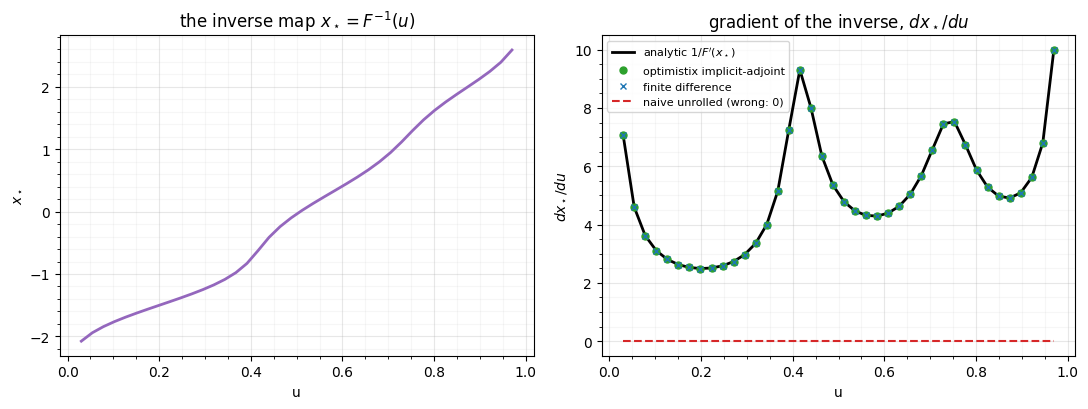

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(uu, x_star, color="tab:purple", lw=2)
axes[0].set(title=r"the inverse map $x_\star = F^{-1}(u)$",
            xlabel="u", ylabel=r"$x_\star$")
style_ax(axes[0])

axes[1].plot(uu, g_analytic, "-", color="k", lw=2, label=r"analytic $1/F'(x_\star)$")
axes[1].plot(uu, g_implicit, "o", color="tab:green", ms=5,
             label="optimistix implicit-adjoint")
axes[1].plot(uu, g_fd, "x", color="tab:blue", ms=5, label="finite difference")
axes[1].plot(uu, g_naive, "--", color="tab:red", lw=1.5,
             label="naive unrolled (wrong: 0)")
axes[1].set(title=r"gradient of the inverse, $dx_\star/du$",
            xlabel="u", ylabel=r"$dx_\star/du$")
axes[1].legend(fontsize=8)
style_ax(axes[1])
fig.tight_layout()

The implicit-adjoint gradient (green) lands exactly on the analytic curve
(black) and the finite-difference reference (blue), while the naive unrolled
gradient (red) is flat at zero — *correct root, useless gradient*. The lesson
generalises: **whenever a flow layer is defined by a solver** (mixture-CDF
inverse, FFJORD's ODE {cite}`grathwohl2019ffjord` in [Part 6](../), residual
flows' fixed point in [Part 9](../)), differentiate the *solution*, not the
*solver*. `optimistix` and `diffrax` give us that adjoint for free.

## 4. The asymmetry on a real flow

`gauss_flows` builds its marginal layers from exactly this mixture-CDF, so a
whole flow inherits the asymmetry: `log_prob` runs the analytic forward maps,
while `sample` runs the bisection inverse inside every marginal layer. We time
both on the same flow (JIT-compiled and warmed up for a fair race).

In [7]:
import gauss_flows as gf

key = jr.key(0)
flow = gf.gaussianization_flow(key, n_dims=2, n_layers=6, n_components=8)
X = jnp.asarray(rng.standard_normal((5000, 2)))


@eqx.filter_jit
def logp(f, x):
    return f.log_prob(x)


@eqx.filter_jit
def samp(f, k):
    return f.sample(k, (5000,))


logp(flow, X).block_until_ready()           # warmup (compile)
samp(flow, key).block_until_ready()

t = time.perf_counter()
for _ in range(5):
    logp(flow, X).block_until_ready()
t_lp = (time.perf_counter() - t) / 5

t = time.perf_counter()
for i in range(5):
    samp(flow, jr.fold_in(key, i)).block_until_ready()
t_s = (time.perf_counter() - t) / 5

print(f"log_prob (forward, analytic)  : {t_lp * 1e3:6.2f} ms / 5000 pts")
print(f"sample   (inverse, bisection) : {t_s * 1e3:6.2f} ms / 5000 pts")
print(f"sample is {t_s / t_lp:.0f}x more expensive than log_prob")

log_prob (forward, analytic)  :   3.52 ms / 5000 pts
sample   (inverse, bisection) : 140.62 ms / 5000 pts
sample is 40x more expensive than log_prob


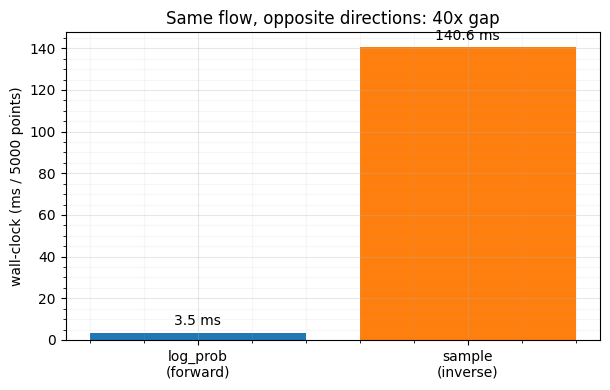

In [8]:
fig, ax = plt.subplots(figsize=(6.2, 4))
bars = ax.bar(["log_prob\n(forward)", "sample\n(inverse)"],
              [t_lp * 1e3, t_s * 1e3], color=["tab:blue", "tab:orange"])
ax.bar_label(bars, fmt="%.1f ms", padding=3)
ax.set(ylabel="wall-clock (ms / 5000 points)",
       title=f"Same flow, opposite directions: {t_s / t_lp:.0f}x gap")
style_ax(ax)
fig.tight_layout()

## 5. The parameterisation choice

The map $T$ and its inverse $T^{-1}$ describe the *same* flow — but we choose
**which one to store as the cheap, closed-form direction**. Whatever we store
cheaply, the *other* direction pays the iterative price (and relies on the
adjoint of §3 for its gradients).

- **Density-estimation flows** call `log_prob` constantly. Store the
  **forward** map cheaply → fast training, slow sampling. *This is what
  `gauss_flows` Gaussianization flows do, hence §4.*
- **Sampling / variational flows** call `sample` constantly. Store the
  **inverse** cheaply → fast sampling, slow density.

In `flowjax` the switch is one wrapper, `Invert`, which swaps a bijector's
forward and inverse.

In [9]:
from flowjax.bijections import Invert

b = gf.MixtureGaussianCDF(n_components=8, shape=(2,))
x = jnp.array([0.4, -0.7])
bi = Invert(b)  # forward and inverse swapped
print("Invert(b).transform == b.inverse :",
      bool(jnp.allclose(bi.transform(x), b.inverse(x))))
print("=> 'forward' and 'inverse' are a labelling choice, not a fixed property.")

Invert(b).transform == b.inverse : True
=> 'forward' and 'inverse' are a labelling choice, not a fixed property.


:::{note} Bridge: this *is* the MAF ↔ IAF story
Masked Autoregressive Flows (MAF) {cite}`papamakarios2017maf` and Inverse
Autoregressive Flows (IAF) {cite}`kingma2016iaf` are the same autoregressive
coupling {cite}`dinh2017realnvp` read in opposite directions. MAF stores the
density direction (parallel `log_prob`, sequential `sample`) — great for
density estimation. IAF stores the sampling direction (parallel `sample`,
sequential `log_prob`) — great as a variational posterior. We meet both as
*bridges* in [Part 5](../) and [Part 11](../); the trade-off is exactly the one
we measured in §4.
:::

## Recap

| concept | takeaway | in code |
|---|---|---|
| two directions | forward for density, inverse for sampling | `flow.log_prob` / `flow.sample` |
| mixture-CDF inverse | a monotone root-find | `optimistix.root_find` + `Bisection` |
| forward gradient | plain autodiff; equals the density $F'(x)$ | `jax.grad(F)` |
| inverse gradient | implicit-function theorem, $dx_\star/du = 1/F'(x_\star)$ | `jax.grad(invF)` (ImplicitAdjoint) |
| never unroll a solver | unrolled bisection gives a *zero* gradient | `invF_unrolled` (counter-example) |
| parameterisation | store the cheap direction; `Invert` swaps it | `flowjax.bijections.Invert` |

**Next up.** We have been mapping *to* a standard Gaussian without asking why
that target. [03 — Why a standard Gaussian?](03_why_standard_gaussian.ipynb)
shows the three properties — maximum entropy, separability, trivial primitives
— that make $\mathcal{N}(0, I)$ the natural destination.